In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.decomposition import PCA

from mlxtend.plotting import plot_decision_regions

In [6]:
# Load Dataset Directly from GitHub
url = "https://raw.githubusercontent.com/Mehedi752/AI-ML-Lab/refs/heads/main/K-Means/datasets/data.csv"

df = pd.read_csv(url)

# View First 5 Rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [17]:
# Github Clone
!git clone https://github.com/Mehedi752/AI-ML-Lab.git

fatal: destination path 'AI-ML-Lab' already exists and is not an empty directory.


In [13]:
%cd AI-ML-Lab
!git pull origin main

/content/AI-ML-Lab
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 5 (delta 1), reused 5 (delta 1), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 507 bytes | 507.00 KiB/s, done.
From https://github.com/Mehedi752/AI-ML-Lab
 * branch            main       -> FETCH_HEAD
   d57efc3..d40cc8e  main       -> origin/main
Updating d57efc3..d40cc8e
Fast-forward
 K-Means Clustering/datasets/custom_data.csv | 11 -----------
 K-Means/datasets/custom_data.csv            | 11 +++++++++++
 2 files changed, 11 insertions(+), 11 deletions(-)
 delete mode 100644 K-Means Clustering/datasets/custom_data.csv


In [14]:
%cd ..

/content


In [18]:
# Load Custom Data from Github
custom_df = pd.read_csv(
    "/content/AI-ML-Lab/K-Means/datasets/custom_data.csv"
)
custom_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,21,20,85
1,24,35,70
2,29,55,60
3,32,40,35
4,45,90,20


In [19]:
# Dataset Exploration

# 1.Shape of Dataset
print("Shape of Dataset:")
print(df.shape)

# 2.Display 5 Random Samples
print("5 Random Samples:")
print(df.sample(5))

# 3.Dataset Information
print("Dataset Info:")
df.info()

# 4.Statistical Summary
print("Statistical Summary:")
print(df.describe())

# 5.Number of unique values in each column.
print("Number of Unique Values in Each Column:")
print(df.nunique())

# 6.Check Missing Values
print("Missing Values:")
print(df.isnull().sum())

# 7.Check Duplicate Rows
print("Duplicate Rows:")
print(df.duplicated().sum())

# 8.Memory Usage
print("Memory Usage:")
print(df.memory_usage())

# 9.Check Skewness
print("Skewness:")
print(df.skew(numeric_only=True))


Shape of Dataset:
(200, 5)
5 Random Samples:
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
60           61    Male   70                  46                      56
11           12  Female   35                  19                      99
77           78    Male   40                  54                      48
64           65    Male   63                  48                      51
158         159    Male   34                  78                       1
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory 

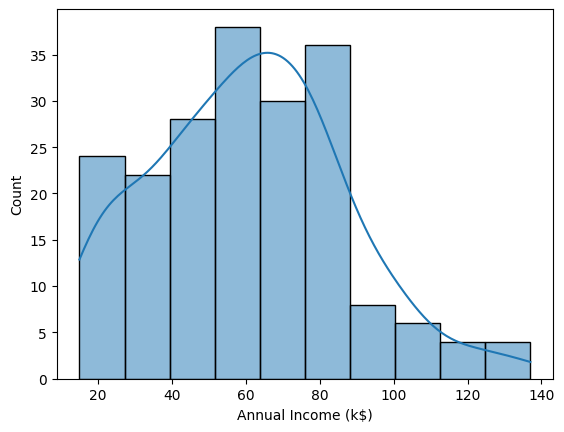

In [20]:
# Income Distribution
sns.histplot(df["Annual Income (k$)"], kde=True)
plt.show()

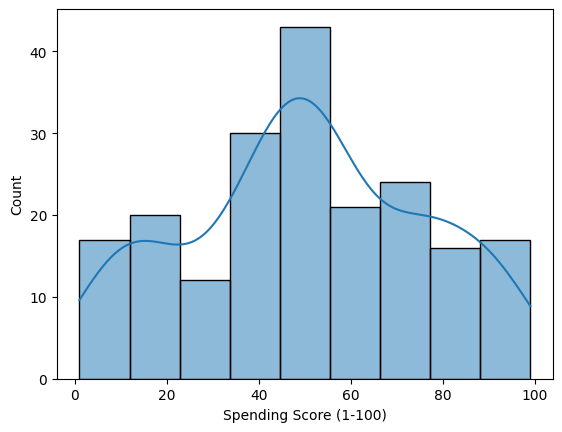

In [21]:
# Spending Score Distribution
sns.histplot(df["Spending Score (1-100)"], kde=True)
plt.show()

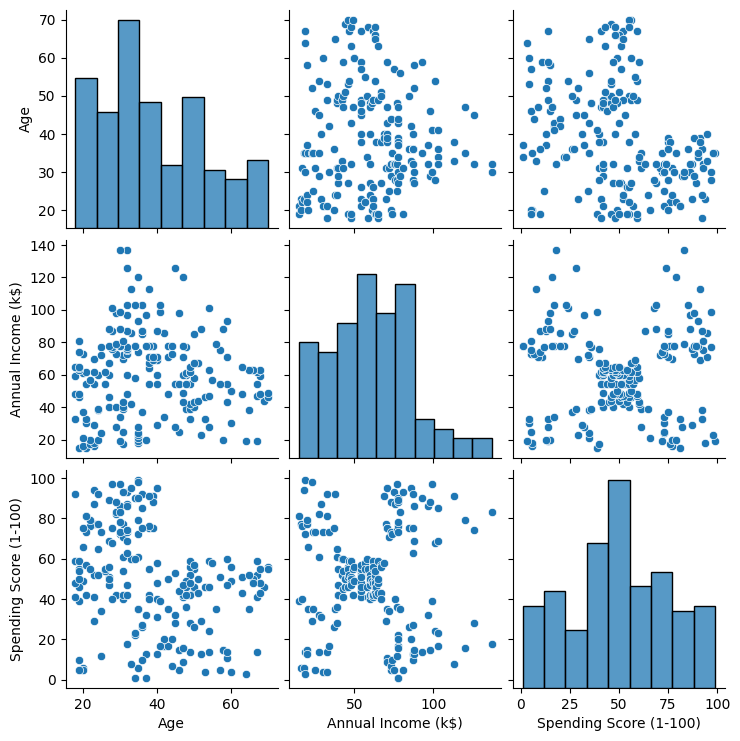

In [22]:
# Pairplot
sns.pairplot(
    df[["Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"]]
)

<Axes: >

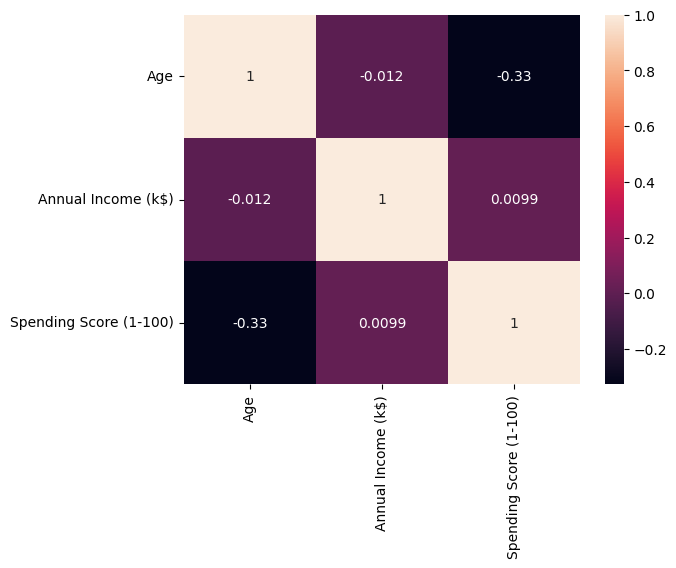

In [23]:
# Correlation Heatmap
sns.heatmap(
    df[["Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"]]
    .corr(),
    annot=True
)

In [25]:
# Feature Selection
X = df[
    [
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

In [26]:
# Scalling/Normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

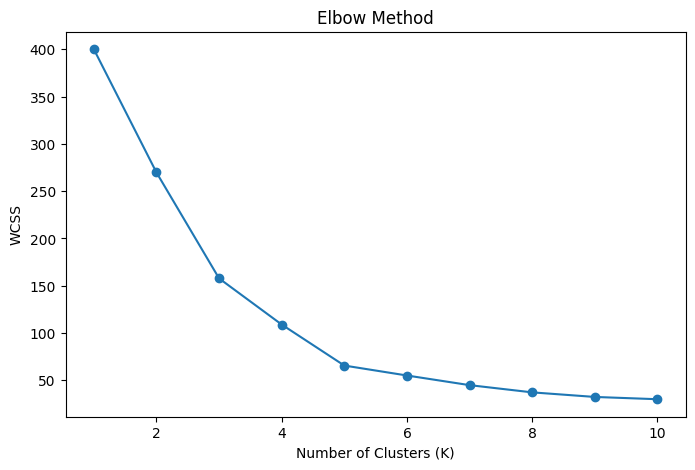

In [28]:
# Elbow Method
from sklearn.cluster import KMeans

wcss = []
for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(
    range(1,11),
    wcss,
    marker='o'
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [29]:
# Optimal K Selection & Model Fitting
optimal_k = 5
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)
kmeans.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [30]:
# Save Model
import joblib
joblib.dump(
    kmeans,
    "210137_kmeans.joblib"
)

['210137_kmeans.joblib']

In [35]:
# Download the Model File from Colab
from google.colab import files
files.download("210137_kmeans.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

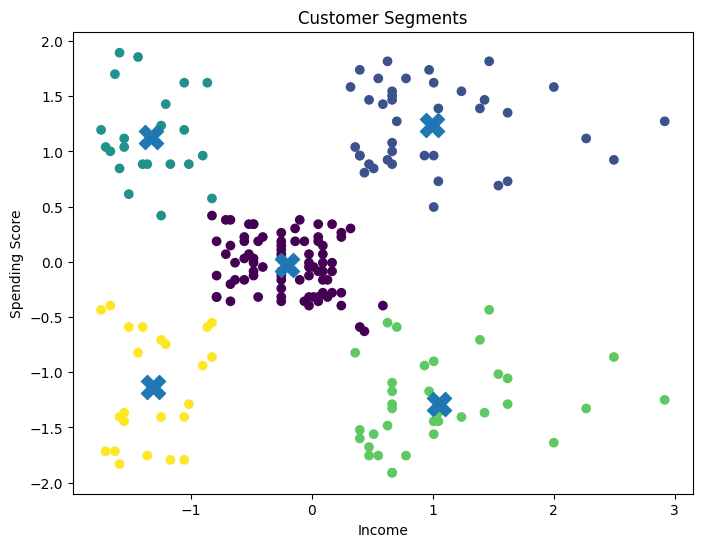

In [31]:
# Cluster Scatter Plot
clusters = kmeans.predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=clusters,
    cmap='viridis'
)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X'
)

plt.title("Customer Segments")
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

In [32]:
# Real-World Prediction
# Scalling Custom
custom_scaled = scaler.transform(
    custom_df[
        [
            "Annual Income (k$)",
            "Spending Score (1-100)"
        ]
    ]
)

# Predict Clusters
custom_clusters = kmeans.predict(custom_scaled)
custom_df["Cluster"] = custom_clusters

# Output Table
custom_df


,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,21,20,85,2
1,24,35,70,2
2,29,55,60,0
3,32,40,35,4
4,45,90,20,3
5,52,110,15,3
6,26,65,75,1
7,37,80,50,0
8,48,95,30,3
9,61,120,10,3


In [33]:
# Cluster Interpretation
### Cluster 0:
# High income + high spending.
# Represents premium customers.

### Cluster 1:
# High income + low spending.
# Represents cautious wealthy customers.

### Cluster 2:
#Low income + high spending.
#Represents impulsive buyers.

### Cluster 3:
# Low income + low spending.
# Represents budget-conscious customers.

### Cluster 4:
# Average income + average spending.
# Represents regular customers.

In [34]:
# Conclusion:
# K-Means Clustering was successfully applied to the Mall Customers dataset for customer segmentation. Data preprocessing and feature scaling were
# performed before clustering. The optimal number of clusters was determined using the Elbow Method. The trained model was saved and later used to
# classify 10 custom customer records collected from real-world observations. The cluster visualization and centroid analysis revealed meaningful customer
# groups based on income and spending behavior, demonstrating how unsupervised learning can support business decision-making and targeted marketing strategies.